In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import inspeqtor.experimental as sq
import seaborn as sns
import scienceplots as scienceplots
import gen_data as ml



/Users/porametpathumsoot/University/PhD/papers/paper_2_code_v2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
TROTTER_STEPS = 2 ** 13
NOISE_STR = 0.01
DETUNE = 0.001
data_model = ml.get_data_model(
    noise_str=NOISE_STR, detune=DETUNE, trotter_steps=TROTTER_STEPS
)
control_sequence = data_model.control_sequence
qubit_info = data_model.qubit_information
_, l2a_fn = sq.control.get_param_array_converter(control_sequence)

signal_fn = sq.physics.signal_func_v5(
    get_envelope=sq.control.get_envelope_transformer(control_sequence=control_sequence),
    drive_frequency=qubit_info.frequency,
    dt=data_model.dt,
)

key = jax.random.key(0)

Text(0, 0.5, 'Amplitude')

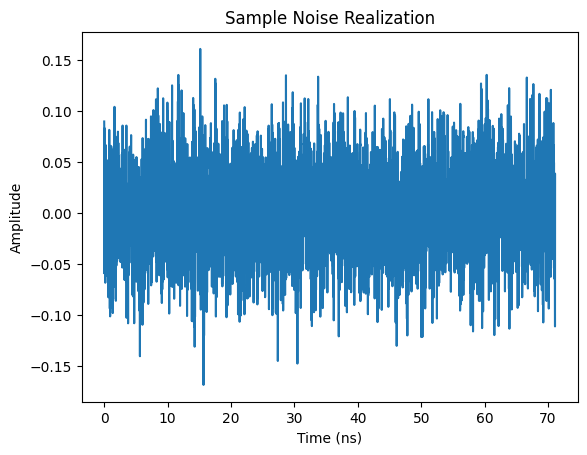

In [36]:
T = control_sequence.total_dt * data_model.dt  # Time(1 / T = dw)
nt = TROTTER_STEPS  # Num.of Discretized Time
F = 1 / T * nt / 2  # Frequency.(GHz)
nw = int(nt / 2)  # Num of Discretized Freq.
dt = T / nt  # Time step size

# Generation of Input Data(Stationary)
t = jnp.linspace(0, T - dt , nt)
dw = F / nw
# w = jnp.linspace(0, F, nw)
w = jnp.arange(0, nw) * dw
spectrum = ml.get_PSD_v1()(w)
noise_fn = ml.make_noise_fn(spectrum, w, nt, dw)
key, subkey = jax.random.split(key)
sample = noise_fn(subkey)
plt.plot(t, NOISE_STR * sample)
plt.title("Sample Noise Realization")
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude")

In [47]:
samples = jax.vmap(noise_fn)(jax.random.split(key, 1000))

print('The mean of the samples is ', np.mean(samples), 'whereas the expected mean is 0.000')
print('The variance of the samples is ', np.var(samples), 'whereas the expected variance is ', np.sum(spectrum)*dw*2)

The mean of the samples is  -0.000748760123108297 whereas the expected mean is 0.000
The variance of the samples is  17.12220706092091 whereas the expected variance is  17.123310813648136


In [39]:
import jax.numpy as jnp

def convert_to_two_sided(one_sided_spectrum: jnp.ndarray, nt: int) -> jnp.ndarray:
    """
    Transforms a one-sided spectrum of length nw into a symmetric,
    two-sided spectrum of length nt compatible with standard FFT layouts.
    """
    # 1. Halve alternating frequencies (index 1 onwards) to split power.
    # Leave the DC component at index 0 untouched.
    scaled_spectrum = one_sided_spectrum.at[1:].multiply(0.5)
    
    # 2. Extract components for the structural assembly
    dc_component = scaled_spectrum[0:1]
    positive_freqs = scaled_spectrum[1:]
    
    # The Nyquist frequency acts as the midpoint boundary when nt is even.
    # We pad it with 0.0 to perfectly match your generator's padding logic.
    nyquist_component = jnp.array([0.0])
    
    # Negative frequencies are a flipped mirror image of the positive frequencies
    negative_freqs = jnp.flip(positive_freqs)
    
    # 3. Concatenate all segments into a single two-sided vector of length nt
    two_sided_spectrum = jnp.concatenate([
        dc_component, 
        positive_freqs, 
        nyquist_component, 
        negative_freqs
    ])
    
    return two_sided_spectrum

In [40]:
import scipy.signal as signal
import matplotlib.pyplot as plt

# 1. Grab your time parameters
# Let's say your time-step dt is 0.002 ns
dt = t[1] - t[0]  # Extract the actual time-step from your time vector
fs = float(1.0 / dt)  # Sampling frequency (in GHz if dt is in ns)

# 2. Generate your noise realizations using your existing JAX setup
num_samples = 1000
# (Assuming your noise function takes a key and returns a time-series noise sample)
raw_noise_samples = NOISE_STR * jax.vmap(noise_fn)(jax.random.split(jax.random.key(123), num_samples))

# Convert the JAX ensemble array to a standard NumPy array for SciPy
# Shape should be (num_samples, time_steps)
noise_matrix_np = np.asarray(raw_noise_samples)

# ====================================================================
# THE SCIPY SHORTCUT
# axis=-1 runs the PSD independently across each noise realization row.
# scaling='density' ensures it calculates a proper Power Spectral Density.
# ====================================================================
frequencies, psd_matrix = signal.periodogram(
    noise_matrix_np, 
    fs=fs, 
    scaling='density', 
    axis=-1
)

# 3. Take the ensemble average across all 1000 realizations to smooth the curve
mean_psd = psd_matrix.mean(axis=0)

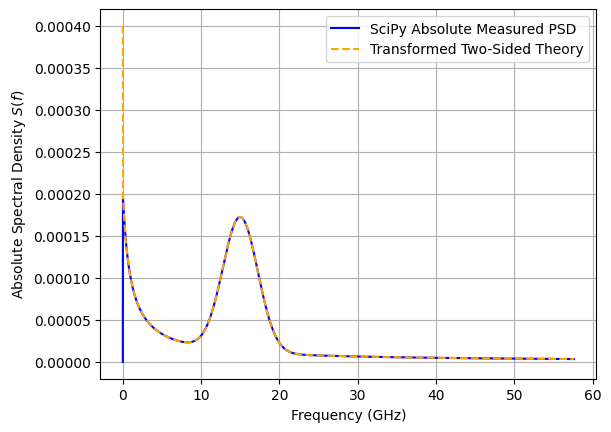

In [41]:
# 1. Generate your standard one-sided spectrum shape (Length: nw)
w = jnp.arange(0, nw) * dw  # Frequencies for the one-sided spectrum
spectrum_one_sided = ml.get_PSD_v1()(w)

# 2. Convert it to a true Two-Sided Spectrum (Length: nt)
spectrum_two_sided = convert_to_two_sided(spectrum_one_sided, nt)

# ====================================================================
# ABSOLUTE UNIT VERIFICATION PLOT
# ====================================================================
# Multiply by NOISE_STR^2 (A^2) to account for your noise amplitude scaling
# Multiply by 4.0 to account for your generator's internal coefficient scaling
theoretical_absolute_psd = spectrum_two_sided * (NOISE_STR ** 2) * 4.0

dt = t[1] - t[0]  # Time step size
frequencies = jnp.fft.fftfreq(nt, d=dt)

# Plot the positive frequency half against SciPy's raw output
plt.plot(frequencies[:nw], mean_psd[:nw], label="SciPy Absolute Measured PSD", color="blue")
plt.plot(frequencies[:nw], theoretical_absolute_psd[:nw], label="Transformed Two-Sided Theory", linestyle="--", color="orange")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Absolute Spectral Density $S(f)$")
plt.legend()
plt.grid(True)
plt.show()